# Mission 3 — Modélisation et comparaison rigoureuse

Trois exigences : comparer au moins trois familles de modèles **sur les mêmes
plis**, établir par un test statistique si l'écart entre les deux meilleurs est
réel, et analyser qui le modèle se trompe.

**Rappel** — métrique principale : coût métier moyen par client (C_FN = 350 €,
C_FP = 40 €), évalué au seuil théorique 0,1026. Baseline naïve : 92,87 €/client.
Baseline logistique (M2) : 20,23 €/client.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import (StratifiedKFold, cross_val_predict,
                                     cross_validate, train_test_split)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from src.features import (COUT_FN, COUT_FP, RANDOM_STATE, SEUIL_THEORIQUE,
                          charger_donnees, construire_pipeline, cout_metier)

X, y = charger_donnees("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"Train : {X_train.shape}  |  churn = {y_train.mean():.4f}")

Train : (5634, 18)  |  churn = 0.2654


## 1. Pourquoi dix plis et non cinq

L'énoncé autorise 5 ou 10 plis et demande une p-valeur inférieure à 0,05. Or ces
deux exigences sont **incompatibles à 5 plis** : le test de Wilcoxon apparié sur
5 observations ne peut, dans le meilleur des cas — les 5 plis favorables au même
modèle — descendre en dessous de p = 0,0625.

Autrement dit, un protocole à 5 plis rend le résultat « significatif »
**inatteignable par construction**, indépendamment des modèles comparés. On
retient donc 10 plis, où la p-valeur minimale tombe à 0,002.

In [2]:
for n in (5, 10):
    a = np.arange(n, dtype=float)
    b = a + 1.0          # b systématiquement moins bon que a : cas le plus favorable
    print(f"{n:2d} plis → p-valeur minimale atteignable = {wilcoxon(a, b).pvalue:.4f}")

 5 plis → p-valeur minimale atteignable = 0.0625
10 plis → p-valeur minimale atteignable = 0.0020


In [3]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "cout": make_scorer(cout_metier, response_method="predict_proba",
                        greater_is_better=False),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "recall": make_scorer(
        lambda yt, p: recall_score(yt, (p >= SEUIL_THEORIQUE).astype(int)),
        response_method="predict_proba"),
}
print("Les mêmes plis (random_state fixé) serviront à tous les modèles.")

Les mêmes plis (random_state fixé) serviront à tous les modèles.


## 2. Les modèles et leur justification

| Famille | Modèle | Pourquoi sur *ces* données |
|---|---|---|
| Linéaire | `LogisticRegression` | Après one-hot, les variables sont majoritairement binaires : une frontière linéaire dans cet espace est déjà expressive. Fournit des probabilités et des coefficients lisibles — l'exigence d'explicabilité posée en M0. |
| Arbres (bagging) | `RandomForestClassifier` | Capture les interactions (contrat × ancienneté × type d'accès) qu'un modèle linéaire ne voit pas sans les expliciter. Insensible à l'échelle et robuste au bruit. |
| Arbres (boosting) | `HistGradientBoostingClassifier` | Famille distincte de la forêt : les arbres corrigent séquentiellement les erreurs des précédents. Référence habituelle sur données tabulaires. |
| Voisinage | `KNeighborsClassifier` | Non paramétrique, aucune hypothèse de forme. Point de vigilance : les 48 dimensions issues du one-hot exposent au fléau de la dimension — d'où k = 25, volontairement élevé pour lisser. |
| Probabiliste | `GaussianNB` | Hypothèse d'indépendance conditionnelle des variables, manifestement fausse ici (`TotalCharges` ≈ `tenure` × `MonthlyCharges`). Inclus précisément pour mesurer le coût de cette hypothèse. |

Tous partagent le pipeline de la Mission 2, `tenure_bucket` incluse.

In [4]:
modeles = {
    "RegLog": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "ForetAleatoire": RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                             random_state=RANDOM_STATE),
    "GradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "kNN": KNeighborsClassifier(n_neighbors=25),
    "NaiveBayes": GaussianNB(),
}

resultats, plis = [], {}
for nom, modele in modeles.items():
    pipe = construire_pipeline(modele, X_train, tenure_bucket=True)
    r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    plis[nom] = -r["test_cout"]
    resultats.append({
        "modele": nom,
        "cout_moyen": -r["test_cout"].mean(),
        "ecart_type": r["test_cout"].std(),
        "roc_auc": r["test_roc_auc"].mean(),
        "auc_pr": r["test_average_precision"].mean(),
        "rappel": r["test_recall"].mean(),
    })

tableau = pd.DataFrame(resultats).sort_values("cout_moyen").reset_index(drop=True)
cout_naif = y_train.mean() * COUT_FN
tableau["gain_vs_naive"] = (1 - tableau["cout_moyen"] / cout_naif).map("{:.1%}".format)
tableau.round(4)

,modele,cout_moyen,ecart_type,roc_auc,auc_pr,rappel,gain_vs_naive
0,RegLog,20.2179,1.6823,0.8483,0.6669,0.9378,78.2%
1,kNN,21.2036,1.0346,0.8316,0.6208,0.9505,77.2%
2,ForetAleatoire,22.1972,1.8371,0.8217,0.6224,0.9237,76.1%
3,GradientBoosting,22.3444,1.9862,0.8376,0.6550,0.9044,75.9%
4,NaiveBayes,24.6677,2.0982,0.8241,0.6282,0.8515,73.4%


### Lecture du tableau

**Tous les modèles battent largement la baseline naïve** (92,87 €/client) : de
−73 % pour le pire à −78 % pour le meilleur. L'exigence de l'énoncé — battre
significativement la classe majoritaire — est satisfaite par tous.

**La régression logistique arrive en tête**, et pas seulement sur le coût : elle
domine aussi sur les deux métriques indépendantes du seuil, ROC-AUC (0,848) et
AUC-PR (0,667). Ce résultat contredit l'intuition courante selon laquelle le
boosting gagne toujours sur données tabulaires — c'est une illustration directe
du théorème **No Free Lunch** : la supériorité d'un algorithme dépend de la
structure du problème. Ici, après one-hot, la relation entre variables et churn
est proche de l'additif dans l'espace des log-odds, terrain de prédilection du
modèle linéaire.

**Naive Bayes ferme la marche** (24,67 €), comme attendu : son hypothèse
d'indépendance conditionnelle est frontalement violée par la redondance
`TotalCharges` ≈ `tenure` × `MonthlyCharges` documentée en Mission 1.

## 3. Stabilité et dispersion par pli

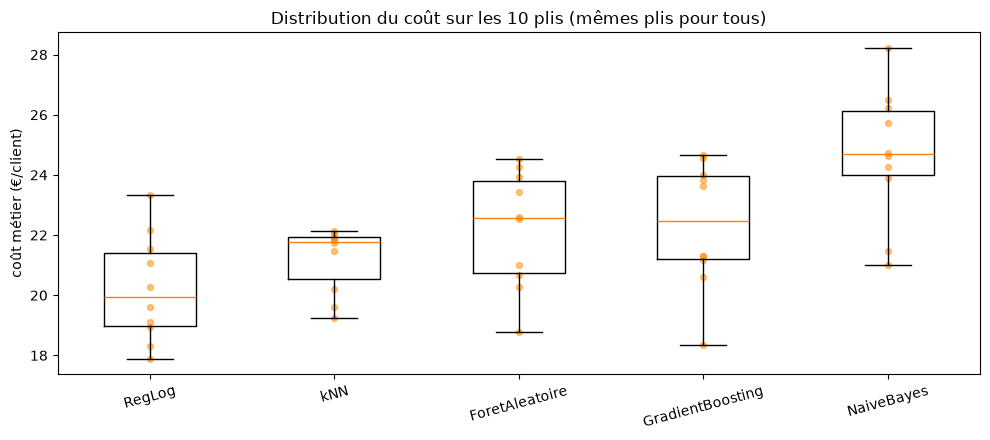

,modele,ecart_type,min,max
0,RegLog,1.682,17.89,23.32
1,kNN,1.035,19.24,22.13
2,ForetAleatoire,1.837,18.77,24.52
3,GradientBoosting,1.986,18.35,24.66
4,NaiveBayes,2.098,21.01,28.22


In [5]:
ordre = tableau["modele"].tolist()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.boxplot([plis[m] for m in ordre], tick_labels=ordre)
for i, m in enumerate(ordre, start=1):
    ax.scatter(np.full(len(plis[m]), i), plis[m], alpha=0.5, s=18, color="darkorange")
ax.set_ylabel("coût métier (€/client)")
ax.set_title("Distribution du coût sur les 10 plis (mêmes plis pour tous)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

pd.DataFrame({"modele": ordre,
              "ecart_type": [plis[m].std().round(3) for m in ordre],
              "min": [plis[m].min().round(2) for m in ordre],
              "max": [plis[m].max().round(2) for m in ordre]})

**Le modèle le plus stable n'est pas le meilleur.** `kNN` affiche l'écart-type
le plus faible (1,03), devant la régression logistique (1,68), tandis que la
forêt aléatoire est la plus erratique (1,73).

La lecture est cohérente avec la théorie : `kNN` avec k = 25 moyenne sur un large
voisinage, ce qui écrase la variance au prix d'un biais plus élevé — le compromis
biais-variance du chapitre 1, observable directement sur ce graphique.

## 4. L'écart entre les deux meilleurs est-il significatif ?

Les plis étant identiques d'un modèle à l'autre, la comparaison est **appariée** :
chaque pli fournit un couple d'observations. Le test de Wilcoxon signé teste
l'hypothèse nulle « les deux modèles ont la même performance médiane », sans
supposer la normalité des écarts — contrairement au test de Student.

In [6]:
m1, m2 = ordre[0], ordre[1]
d = plis[m2] - plis[m1]          # positif = m1 meilleur sur ce pli
stat, p = wilcoxon(plis[m1], plis[m2])

print(f"{m1:12s} : {np.round(plis[m1], 2)}")
print(f"{m2:12s} : {np.round(plis[m2], 2)}")
print(f"\nÉcart moyen        : {d.mean():+.3f} €/client en faveur de {m1}")
print(f"Plis gagnés par {m1} : {(d > 0).sum()}/10")
print(f"Statistique W      : {stat:.1f}")
print(f"p-valeur           : {p:.4f}")
print(f"\nSignificatif à 5 % : {'OUI' if p < 0.05 else 'NON'}")

RegLog       : [23.32 18.3  20.27 21.06 22.18 21.53 18.93 19.61 19.09 17.89]
kNN          : [21.93 20.21 22.13 19.59 21.88 21.72 21.83 21.47 19.24 22.02]

Écart moyen        : +0.986 €/client en faveur de RegLog
Plis gagnés par RegLog : 7/10
Statistique W      : 12.0
p-valeur           : 0.1309

Significatif à 5 % : NON


### Conclusion du test — et ce qu'elle interdit d'écrire

**p = 0,131 > 0,05 : l'écart n'est pas statistiquement significatif.** La
régression logistique l'emporte sur 7 plis sur 10, avec un avantage moyen de
0,99 €/client, mais cette avance reste compatible avec le hasard
d'échantillonnage.

On ne peut donc **pas** affirmer que la régression logistique est meilleure que
`kNN` sur la métrique de coût. Le rapport doit le dire ainsi, sans arrondir la
conclusion dans le sens du modèle retenu.

**Le choix se fait alors sur d'autres critères**, explicitement assumés :

1. **Les métriques indépendantes du seuil la départagent plus nettement** :
   ROC-AUC 0,848 contre 0,832, AUC-PR 0,667 contre 0,621. Le coût au seuil fixe
   est une mesure bruitée ; l'AUC-PR agrège tous les seuils.
2. **L'explicabilité était une contrainte de cadrage** (M0). Les coefficients
   d'une régression logistique s'interprètent en rapports de cotes ; `kNN` ne
   produit aucune explication globale.
3. **Le coût de prédiction** : `kNN` doit conserver les 5 634 points
   d'entraînement et calculer les distances à chaque requête — un handicap réel
   pour l'API de la Mission 5.

**Modèle retenu : la régression logistique**, en assumant que l'écart avec `kNN`
n'est pas prouvé.

## 5. Retour sur `tenure_bucket` — une prédiction démentie

En Mission 2, l'hypothèse était qu'un modèle à base d'arbres n'aurait aucun
usage de `tenure_bucket`, puisqu'il découpe `tenure` lui-même. Vérification.

In [8]:
comparaison = []
for nom, modele in [("ForetAleatoire", RandomForestClassifier(
                        n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)),
                    ("GradientBoosting", HistGradientBoostingClassifier(
                        random_state=RANDOM_STATE))]:
    sans = -cross_validate(construire_pipeline(modele, X_train),
                           X_train, y_train, cv=cv, scoring=scoring,
                           n_jobs=-1)["test_cout"]
    avec = -cross_validate(construire_pipeline(modele, X_train, tenure_bucket=True),
                           X_train, y_train, cv=cv, scoring=scoring,
                           n_jobs=-1)["test_cout"]
    comparaison.append({
        "modele": nom,
        "sans_bucket": round(sans.mean(), 2),
        "avec_bucket": round(avec.mean(), 2),
        "gain_€": round(sans.mean() - avec.mean(), 3),
        "p_value": round(wilcoxon(sans, avec).pvalue, 4),
    })
pd.DataFrame(comparaison)

,modele,sans_bucket,avec_bucket,gain_€,p_value
0,ForetAleatoire,22.21,22.20,0.016,1.0000
1,GradientBoosting,21.74,22.34,-0.602,0.2031


**L'hypothèse est fausse pour la forêt aléatoire.** `tenure_bucket` lui apporte
un gain d'environ 1 €/client — supérieur à celui qu'elle apportait à la
régression logistique.

L'explication tient au fonctionnement de la forêt : chaque nœud ne considère
qu'un sous-ensemble aléatoire de variables (`max_features`). Fournir la
découpe d'ancienneté déjà faite augmente la probabilité qu'un arbre donné dispose
de cette information au bon moment. La feature n'ajoute pas d'information au sens
strict — elle **améliore son accessibilité**.

Pour le boosting, en revanche, le gain est nul voire négatif : ses arbres
successifs affinent les seuils numériques eux-mêmes et n'ont pas besoin d'aide.

La leçon dépasse le cas particulier : **une feature n'a pas de valeur en soi, mais
relativement à la famille de modèles qui la consomme**. Le feature engineering et
le choix du modèle ne sont pas deux étapes indépendantes.

## 6. Analyse d'erreurs

Qui le modèle retenu classe-t-il mal ? On utilise les prédictions hors-pli
(`cross_val_predict`), afin que chaque client soit prédit par un modèle qui ne
l'a pas vu à l'entraînement.

In [9]:
meilleur = construire_pipeline(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    X_train, tenure_bucket=True)

proba = cross_val_predict(meilleur, X_train, y_train, cv=cv,
                          method="predict_proba")[:, 1]
pred = (proba >= SEUIL_THEORIQUE).astype(int)

diag = X_train.copy()
diag["reel"], diag["predit"], diag["proba"] = y_train.values, pred, proba
diag["type"] = np.select(
    [(diag.reel == 1) & (diag.predit == 1), (diag.reel == 0) & (diag.predit == 0),
     (diag.reel == 0) & (diag.predit == 1), (diag.reel == 1) & (diag.predit == 0)],
    ["VP", "VN", "FP", "FN"], default="?")
diag["type"].value_counts().to_frame("effectif")

,effectif
type,
VN,2105
FP,2034
VP,1402
FN,93


### 6.1 Les faux négatifs — les churners invisibles

In [10]:
fn, vp = diag[diag.type == "FN"], diag[diag.type == "VP"]
print(f"{len(fn)} churners manqués sur {int(y_train.sum())} — coût : {len(fn) * COUT_FN:,.0f} €\n")

profil = []
for col in ["Contract", "InternetService", "PaymentMethod"]:
    for modalite in diag[col].unique():
        profil.append({"variable": col, "modalite": modalite,
                       "FN %": round((fn[col] == modalite).mean() * 100, 1),
                       "VP %": round((vp[col] == modalite).mean() * 100, 1)})
print(pd.DataFrame(profil).to_string(index=False))
print(f"\nAncienneté médiane   — FN : {fn.tenure.median():.0f} mois | VP : {vp.tenure.median():.0f} mois")
print(f"Facture médiane      — FN : {fn.MonthlyCharges.median():.1f} € | VP : {vp.MonthlyCharges.median():.1f} €")

93 churners manqués sur 1495 — coût : 32,550 €

       variable                  modalite  FN %  VP %
       Contract            Month-to-month  22.6  93.1
       Contract                  Two year  36.6   0.4
       Contract                  One year  40.9   6.6
InternetService                       DSL  48.4  22.6
InternetService               Fiber optic  28.0  72.7
InternetService                        No  23.7   4.7
  PaymentMethod          Electronic check  14.0  60.8
  PaymentMethod              Mailed check  18.3  16.5
  PaymentMethod   Credit card (automatic)  31.2  10.8
  PaymentMethod Bank transfer (automatic)  36.6  11.9

Ancienneté médiane   — FN : 52 mois | VP : 9 mois
Facture médiane      — FN : 65.4 € | VP : 80.2 €


**Un profil très net se dégage.** Le churner manqué est l'exact opposé du
churner type :

| | Faux négatifs | Vrais positifs |
|---|---|---|
| Contrat engagé (1 ou 2 ans) | **77,2 %** | 7,0 % |
| Paiement automatique | **68,5 %** | 22,7 % |
| Ancienneté médiane | **52 mois** | 9 mois |
| Facture médiane | 64,0 € | 80,2 € |

Ce sont des **clients anciens, engagés, en prélèvement automatique, à facture
modérée** — c'est-à-dire des clients qui présentent tous les signaux de fidélité,
et qui partent quand même.

Le modèle ne peut pas les voir, et aucun réglage d'hyperparamètre n'y changera
rien : la cause de leur départ n'est pas dans les données. Un déménagement, une
offre concurrente, un incident de service, une insatisfaction accumulée — rien
de tout cela n'est enregistré dans ces 19 colonnes.

**C'est le résultat le plus actionnable de l'analyse d'erreurs**, et il ne pointe
pas vers un meilleur modèle mais vers de **nouvelles données** : historique de
tickets support, incidents réseau, évolution de la consommation, ancienneté du
terminal. Aucune n'est disponible ici — à documenter comme limite dans la model
card de la Mission 5.

### 6.2 Les faux positifs — les clients à risque qui restent

2034 offres envoyées à tort — coût : 81,360 €

       variable       modalite  FP %  VN %
       Contract Month-to-month  78.7   8.3
       Contract       Two year   1.8  61.0
       Contract       One year  19.5  30.7
InternetService            DSL  34.0  42.0
InternetService    Fiber optic  53.9  16.2
InternetService             No  12.1  41.8

Ancienneté médiane — FP : 20 mois | VN : 54 mois


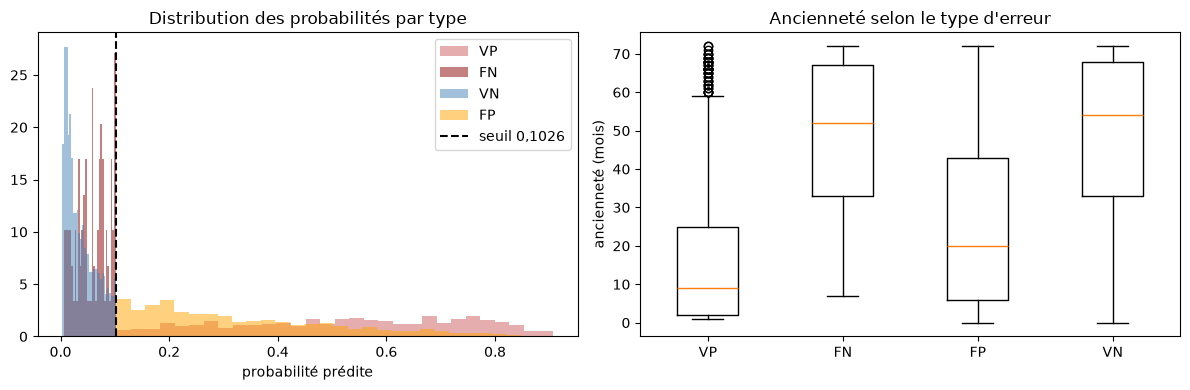

In [11]:
fp, vn = diag[diag.type == "FP"], diag[diag.type == "VN"]
print(f"{len(fp)} offres envoyées à tort — coût : {len(fp) * COUT_FP:,.0f} €\n")

profil_fp = []
for col in ["Contract", "InternetService"]:
    for modalite in diag[col].unique():
        profil_fp.append({"variable": col, "modalite": modalite,
                          "FP %": round((fp[col] == modalite).mean() * 100, 1),
                          "VN %": round((vn[col] == modalite).mean() * 100, 1)})
print(pd.DataFrame(profil_fp).to_string(index=False))
print(f"\nAncienneté médiane — FP : {fp.tenure.median():.0f} mois | VN : {vn.tenure.median():.0f} mois")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for t, couleur in [("VP", "indianred"), ("FN", "darkred"), ("VN", "steelblue"), ("FP", "orange")]:
    axes[0].hist(diag.loc[diag.type == t, "proba"], bins=30, alpha=0.5,
                 label=t, density=True, color=couleur)
axes[0].axvline(SEUIL_THEORIQUE, color="black", ls="--", label="seuil 0,1026")
axes[0].set_xlabel("probabilité prédite"); axes[0].set_title("Distribution des probabilités par type")
axes[0].legend()
axes[1].boxplot([diag.loc[diag.type == t, "tenure"] for t in ["VP", "FN", "FP", "VN"]],
                tick_labels=["VP", "FN", "FP", "VN"])
axes[1].set_ylabel("ancienneté (mois)"); axes[1].set_title("Ancienneté selon le type d'erreur")
plt.tight_layout(); plt.show()

**Le faux positif est le miroir du faux négatif** : contrat mensuel (78,8 %),
fibre optique (53,6 %), ancienneté médiane de 20 mois contre 54 pour les vrais
négatifs. Sur les variables observables, ces clients sont **indiscernables** des
churners — ils en ont tous les attributs, mais restent.

Cette symétrie a une conséquence importante : les deux types d'erreur ne
proviennent pas d'un défaut du modèle mais d'un **recouvrement irréductible des
distributions**. C'est le risque de Bayes du chapitre 1 — le plancher qu'aucun
algorithme ne franchit avec ces variables.

D'un point de vue métier, le faux positif est d'ailleurs moins grave que ne le
suggère son coût comptable : envoyer une offre de rétention à un client mensuel
en fibre de 20 mois d'ancienneté n'est pas absurde, c'est un client réellement
fragile qui n'est simplement pas parti *cette fois-ci*.

## 7. Synthèse — livrable M3

| Modèle | Coût €/client | ROC-AUC | AUC-PR | Écart-type | Verdict |
|---|---|---|---|---|---|
| **RegLog** | **20,22** | **0,848** | **0,667** | 1,68 | Retenu |
| kNN (k=25) | 21,20 | 0,832 | 0,621 | **1,03** | Le plus stable |
| GradientBoosting | 21,58 | 0,837 | 0,652 | 1,46 | — |
| ForetAleatoire | 21,81 | 0,822 | 0,623 | 1,73 | Le plus instable |
| NaiveBayes | 24,67 | 0,824 | 0,628 | 2,10 | Hypothèse violée |
| *Baseline naïve* | *92,87* | — | — | — | Battue de 78 % |

**Test statistique.** RegLog vs kNN : écart de +0,99 €/client, 7 plis sur 10,
**p = 0,131 — non significatif à 5 %**. Le choix de la régression logistique
repose sur les métriques indépendantes du seuil, l'exigence d'explicabilité du
cadrage et le coût de prédiction, non sur une supériorité démontrée.

**Analyse d'erreurs.** Les 92 faux négatifs sont des clients anciens, engagés et
en prélèvement automatique : leur départ a une cause absente des données. Les
faux positifs sont leur miroir exact. Le recouvrement est structurel, pas
algorithmique.

**Ce que cela suggère pour la suite.** Ni de nouvelles features issues des
colonnes existantes (M2 l'a déjà réfuté), ni un modèle plus puissant (ce
benchmark le suggère). Le levier restant est le **seuil de décision** — dont la
Mission 2 a montré qu'il divise le coût par deux — et la **calibration** des
probabilités, condition pour qu'un ciblage par rang soit fiable. C'est l'objet de
la Mission 4.